Pesquise sobre calibração de câmera.

Leia os tutoriais de calibração do openCV.

Para fazer em dupla

Escolha uma câmera, execute a calibração. No VRI temos um tabuleiro quadriculado grande, se quiser utilizar.

Experimente obter as matrizes e também realizar a remoção da disstorção provocada pela câmera.

Crie experimento que, dada posição de pontos no espaço 3D, determine as coordenadas em algumas imagens. Confira. Mostre isso no relatório.

Se você achar o assunto interessante, pode calibrar duas câmeras em configuração estéreo e determinar a localização no espaço de um ponto presente em ambas imagens.

Submeta relatório sucinto e link para o git

In [1]:
# ===== Bibliotecas =====
import os, sys, glob, json
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image, ImageOps

try:                                    # abre fotos .HEIC do iPhone
    from pillow_heif import register_heif_opener
    register_heif_opener()
except ImportError:
    print("pillow-heif não instalado: arquivos .heic não serão lidos")

NO_COLAB = "google.colab" in sys.modules
print("OpenCV", cv2.__version__, "| Colab:", NO_COLAB)

OpenCV 5.0.0 | Colab: False


In [2]:
# ===== ENVIO DAS FOTOS (opcional) =====
# Pode pular esta célula se colocar as fotos direto no Drive, nas pastas de entrada/
#import zipfile
#
#def enviar_para(pasta):
#    if not NO_COLAB:
#        print("fora do Colab: copie os arquivos manualmente para", pasta); return
#    from google.colab import files
#    try:
#        enviados = files.upload()
#    except Exception:
#        enviados = {}
#    for nome in enviados:
#        if nome.lower().endswith(".zip"):
#            with zipfile.ZipFile(nome) as z:
#                z.extractall(pasta)
#            os.remove(nome)
#        else:
#            os.replace(nome, os.path.join(pasta, nome))
#    print(len(os.listdir(pasta)), "arquivos em", pasta)
#
#if not USAR_SINTETICAS:
#    print("fotos de CALIBRAÇÃO:"); enviar_para(PASTA_CALIB)
#    print("fotos de TESTE:");      enviar_para(PASTA_TESTE)

## Gerador de Fotos Sintéticas

Para validarmos o código antes de usar as fotos reais, utilizaremos imagens sintéticas com a matriz da câmera $K$ e parâmetros de distorção conhecidos. 

In [3]:
W, H = 1600, 1200                                   # tamanho da "foto"
K_REAL = np.array([[1400.0, 0, 810.0],              # a verdade que queremos recuperar
                   [0, 1395.0, 590.0],
                   [0, 0, 1.0]])
DIST_REAL = np.array([-0.28, 0.12, 0.001, -0.0015, -0.02])
PX = 60                                             # pixels por quadrado na textura
rng = np.random.default_rng(7)

# --- 1. desenha o tabuleiro como uma "folha" plana ---
nx, ny = CANTOS[0] + 1, CANTOS[1] + 1
PLANO = np.full(((ny + 2) * PX, (nx + 2) * PX), 245, np.uint8)   # margem branca
for i in range(ny):
    for j in range(nx):
        if (i + j) % 2 == 0:
            PLANO[(i+1)*PX:(i+2)*PX, (j+1)*PX:(j+2)*PX] = 20
ESC = QUAD_MM / PX                                  # milímetros por pixel da textura

# --- 2. para cada pixel da foto, qual raio sai da câmera ---
u, v = np.meshgrid(np.arange(W, dtype=np.float32), np.arange(H, dtype=np.float32))
pixels = np.stack([u.ravel(), v.ravel()], 1).reshape(-1, 1, 2)
norm = cv2.undistortPoints(pixels, K_REAL, DIST_REAL).reshape(-1, 2)
RAIOS = np.hstack([norm, np.ones((len(norm), 1))])

def render(rvec, tvec):
    """Desenha o tabuleiro visto de uma posição/orientação da câmera."""
    R, _ = cv2.Rodrigues(rvec)      # vetor de rotação -> matriz de rotação
    t = tvec.reshape(3)
    n = R[:, 2]                     # normal do plano do tabuleiro
    s = (n @ t) / (RAIOS @ n)       # onde cada raio encontra o plano
    P = RAIOS * s[:, None]          # ponto 3D atingido, no sistema da câmera
    Pw = (P - t) @ R                # mesmo ponto, no sistema do tabuleiro
    mx = (Pw[:, 0] / ESC + PX).astype(np.float32).reshape(H, W)
    my = (Pw[:, 1] / ESC + PX).astype(np.float32).reshape(H, W)
    img = cv2.remap(PLANO, mx, my, cv2.INTER_LINEAR,
                    borderMode=cv2.BORDER_CONSTANT, borderValue=160)
    img[s.reshape(H, W) <= 0] = 160                      # atrás da câmera
    img = cv2.GaussianBlur(img, (3, 3), 0.6)             # leve desfoque
    return np.clip(img.astype(np.float32) + rng.normal(0, 2.5, img.shape),
                   0, 255).astype(np.uint8)              # ruído do sensor

def cabe_na_foto(rvec, tvec, margem=45):
    """Só aceita a pose se o tabuleiro inteiro aparecer na imagem."""
    ox, oy = np.meshgrid(np.arange(CANTOS[0]), np.arange(CANTOS[1]))
    pts = np.stack([ox.ravel() * QUAD_MM, oy.ravel() * QUAD_MM, np.zeros(ox.size)], 1)
    p = cv2.projectPoints(pts, rvec, tvec, K_REAL, DIST_REAL)[0].reshape(-1, 2)
    return (p[:,0].min() > margem and p[:,0].max() < W - margem and
            p[:,1].min() > margem and p[:,1].max() < H - margem)

# --- 3. sorteia poses e salva as imagens ---
N_CALIB, N_TESTE = 25, 3
feitas = 0
while feitas < N_CALIB + N_TESTE:
    rvec = np.array([rng.uniform(-.5, .5), rng.uniform(-.55, .55),
                     rng.uniform(-.4, .4)]).reshape(3, 1)
    tvec = np.array([rng.uniform(-80, 80), rng.uniform(-60, 60),
                     rng.uniform(380, 750)]).reshape(3, 1)
    if not cabe_na_foto(rvec, tvec):
        continue
    img = render(rvec, tvec)
    if feitas < N_CALIB:
        cv2.imwrite(os.path.join(PASTA_CALIB, f"sint_{feitas:02d}.png"), img)
    else:
        cv2.imwrite(os.path.join(PASTA_TESTE, f"sint_teste_{feitas-N_CALIB:02d}.png"), img)
    feitas += 1

np.savez(os.path.join(BASE, "verdade_sintetica.npz"), K=K_REAL, dist=DIST_REAL)
print(f"{N_CALIB} imagens em fotos_calibracao/ e {N_TESTE} em fotos_teste/")

# mostra algumas
fig, ax = plt.subplots(1, 4, figsize=(16, 3.4))
for a, p in zip(ax, sorted(glob.glob(os.path.join(PASTA_CALIB, "*.png")))[:4]):
    a.imshow(cv2.imread(p, cv2.IMREAD_GRAYSCALE), cmap="gray", vmin=0, vmax=255)
    a.axis("off")
plt.tight_layout(); plt.show()

NameError: name 'CANTOS' is not defined

In [9]:
# ===== ENVIO DAS FOTOS (opcional) =====
# Pode pular esta célula se colocar as fotos direto no Drive, nas pastas de entrada/
#import zipfile
#
#def enviar_para(pasta):
#    if not NO_COLAB:
#        print("fora do Colab: copie os arquivos manualmente para", pasta); return
#    from google.colab import files
#    try:
#        enviados = files.upload()
#    except Exception:
#        enviados = {}
#    for nome in enviados:
#        if nome.lower().endswith(".zip"):
#            with zipfile.ZipFile(nome) as z:
#                z.extractall(pasta)
#            os.remove(nome)
#        else:
#            os.replace(nome, os.path.join(pasta, nome))
#    print(len(os.listdir(pasta)), "arquivos em", pasta)
#
#if not USAR_SINTETICAS:
#    print("fotos de CALIBRAÇÃO:"); enviar_para(PASTA_CALIB)
#    print("fotos de TESTE:");      enviar_para(PASTA_TESTE)

In [10]:
# ===== GERADOR DE FOTOS SINTÉTICAS =====
W, H = 1600, 1200                                   # tamanho da "foto"
K_REAL = np.array([[1400.0, 0, 810.0],              # a verdade que queremos recuperar
                   [0, 1395.0, 590.0],
                   [0, 0, 1.0]])
DIST_REAL = np.array([-0.28, 0.12, 0.001, -0.0015, -0.02])   # k1 k2 p1 p2 k3
BASE_REAL = 120.0                                   # distância entre as câmeras estéreo (mm)
PX = 60                                             # pixels por quadrado na textura
rng = np.random.default_rng(7)

nx, ny = CANTOS[0] + 1, CANTOS[1] + 1
PLANO = np.full(((ny + 2) * PX, (nx + 2) * PX), 245, np.uint8)   # margem branca
for i in range(ny):
    for j in range(nx):
        if (i + j) % 2 == 0:
            PLANO[(i+1)*PX:(i+2)*PX, (j+1)*PX:(j+2)*PX] = 20
ESC = QUAD_MM / PX                                  # milímetros por pixel da textura

# para cada pixel da foto, a direção do raio que sai da câmera
u, v = np.meshgrid(np.arange(W, dtype=np.float32), np.arange(H, dtype=np.float32))
pixels = np.stack([u.ravel(), v.ravel()], 1).reshape(-1, 1, 2)
norm = cv2.undistortPoints(pixels, K_REAL, DIST_REAL).reshape(-1, 2)
RAIOS = np.hstack([norm, np.ones((len(norm), 1))])

def render(rvec, tvec):
    # desenha o tabuleiro visto de uma posição/orientação da câmera
    R, _ = cv2.Rodrigues(rvec)
    t = tvec.reshape(3)
    n = R[:, 2]                     # normal do plano do tabuleiro
    with np.errstate(divide="ignore", invalid="ignore"):
        s = (n @ t) / (RAIOS @ n)   # onde cada raio encontra o plano
    P = RAIOS * s[:, None]
    Pw = (P - t) @ R                # ponto no sistema do tabuleiro
    mx = (Pw[:, 0] / ESC + PX).astype(np.float32).reshape(H, W)
    my = (Pw[:, 1] / ESC + PX).astype(np.float32).reshape(H, W)
    img = cv2.remap(PLANO, mx, my, cv2.INTER_LINEAR,
                    borderMode=cv2.BORDER_CONSTANT, borderValue=160)
    img[~(s.reshape(H, W) > 0)] = 160
    img = cv2.GaussianBlur(img, (3, 3), 0.6)
    return np.clip(img.astype(np.float32) + rng.normal(0, 2.5, img.shape),
                   0, 255).astype(np.uint8)

def cabe_na_foto(rvec, tvec, margem=45):
    ox, oy = np.meshgrid(np.arange(CANTOS[0]), np.arange(CANTOS[1]))
    pts = np.stack([ox.ravel() * QUAD_MM, oy.ravel() * QUAD_MM, np.zeros(ox.size)], 1)
    p = cv2.projectPoints(pts, rvec, tvec, K_REAL, DIST_REAL)[0].reshape(-1, 2)
    return (p[:,0].min() > margem and p[:,0].max() < W - margem and
            p[:,1].min() > margem and p[:,1].max() < H - margem)

def sorteia_pose():
    rvec = np.array([rng.uniform(-.5, .5), rng.uniform(-.55, .55),
                     rng.uniform(-.4, .4)]).reshape(3, 1)
    tvec = np.array([rng.uniform(-80, 80), rng.uniform(-60, 60),
                     rng.uniform(380, 750)]).reshape(3, 1)
    return rvec, tvec

if USAR_SINTETICAS:
    N_CALIB, N_TESTE, N_ESTEREO = 25, 3, 12
    poses_teste = []
    feitas = 0
    while feitas < N_CALIB + N_TESTE:
        rvec, tvec = sorteia_pose()
        if not cabe_na_foto(rvec, tvec):
            continue
        img = render(rvec, tvec)
        if feitas < N_CALIB:
            cv2.imwrite(os.path.join(PASTA_CALIB, f"sint_{feitas:02d}.png"), img)
        else:
            cv2.imwrite(os.path.join(PASTA_TESTE, f"sint_teste_{feitas-N_CALIB:02d}.png"), img)
            poses_teste.append((rvec.ravel(), tvec.ravel()))
        feitas += 1

    # pares estéreo: câmera direita deslocada BASE_REAL mm no eixo x da esquerda
    feitas = 0
    while feitas < N_ESTEREO:
        rvec, tvec = sorteia_pose()
        tvec_d = tvec - np.array([[BASE_REAL], [0], [0]])
        if not (cabe_na_foto(rvec, tvec) and cabe_na_foto(rvec, tvec_d)):
            continue
        cv2.imwrite(os.path.join(PASTA_ESQ, f"par_{feitas:02d}.png"), render(rvec, tvec))
        cv2.imwrite(os.path.join(PASTA_DIR, f"par_{feitas:02d}.png"), render(rvec, tvec_d))
        feitas += 1

    np.savez(os.path.join(ENTRADA, "verdade_sintetica.npz"), K=K_REAL, dist=DIST_REAL,
             base=BASE_REAL, poses_teste=np.array([np.r_[r, t] for r, t in poses_teste]))
    print(f"{N_CALIB} de calibração, {N_TESTE} de teste, {N_ESTEREO} pares estéreo")

In [ ]:
# ===== LEITURA (JPG, PNG e HEIC) =====
def listar(pasta):
    return sorted(p for p in glob.glob(os.path.join(pasta, "*"))
                  if p.lower().endswith(EXT))

def carregar(caminho):
    # PIL + exif_transpose: respeita a orientação gravada pelo celular
    if caminho.lower().endswith((".heic", ".heif", ".jpg", ".jpeg")):
        img = ImageOps.exif_transpose(Image.open(caminho))
        return cv2.cvtColor(np.array(img.convert("RGB")), cv2.COLOR_RGB2BGR)
    return cv2.imread(caminho, cv2.IMREAD_COLOR)

arquivos = listar(PASTA_CALIB)
testes = listar(PASTA_TESTE)
print(len(arquivos), "fotos de calibração |", len(testes), "de teste")

TAM = carregar(arquivos[0]).shape[:2][::-1]         # (largura, altura)
print("resolução:", TAM)

25 fotos de calibração | 3 de teste
resolução: (1600, 1200)


tabuleiro detectado em 25 de 25 fotos


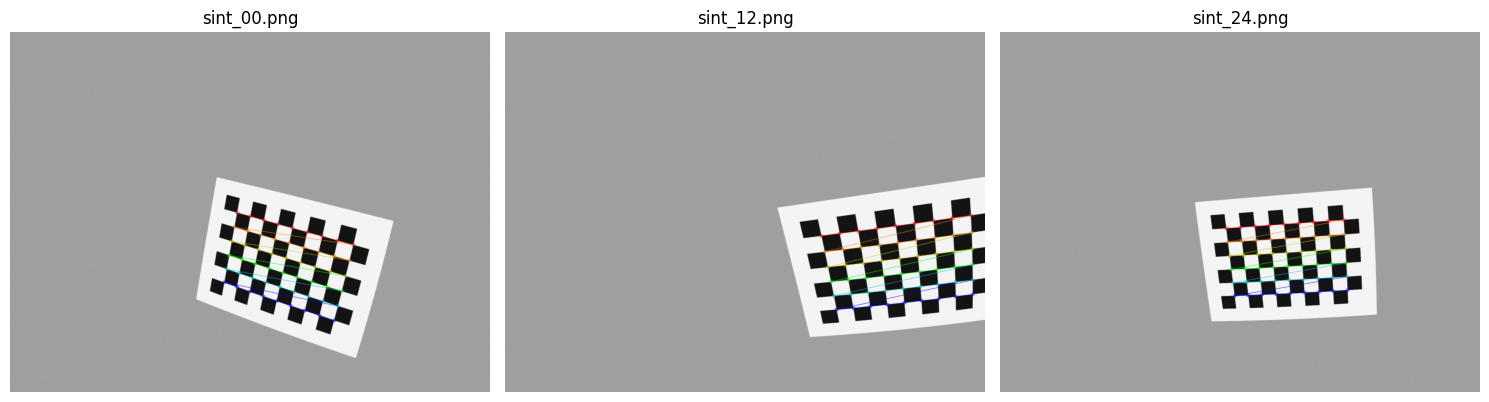

In [ ]:
# ===== PONTOS 3D DO TABULEIRO (Z = 0) =====
OBJP = np.zeros((CANTOS[0] * CANTOS[1], 3), np.float32)
OBJP[:, :2] = np.mgrid[0:CANTOS[0], 0:CANTOS[1]].T.reshape(-1, 2) * QUAD_MM

CRIT = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 50, 1e-4)

def detectar(img, lado_max=1600):
    cinza = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) if img.ndim == 3 else img
    esc = min(1.0, lado_max / max(cinza.shape))
    peq = cv2.resize(cinza, None, fx=esc, fy=esc, interpolation=cv2.INTER_AREA) if esc < 1 else cinza
    flags = cv2.CALIB_CB_ADAPTIVE_THRESH + cv2.CALIB_CB_NORMALIZE_IMAGE
    ok, c = cv2.findChessboardCorners(peq, CANTOS, flags)
    if not ok:                                   # detector alternativo, mais robusto
        ok, c = cv2.findChessboardCornersSB(peq, CANTOS, cv2.CALIB_CB_EXHAUSTIVE)
    if not ok:
        return None
    c = (c / esc).astype(np.float32)
    jan = max(5, int(round(5 / esc)))
    return cv2.cornerSubPix(cinza, c, (jan, jan), (-1, -1), CRIT)

obj_pts, img_pts, usadas = [], [], []
for p in arquivos:
    img = carregar(p)
    if img.shape[:2][::-1] != TAM:
        print("  tamanho diferente, ignorada:", os.path.basename(p)); continue
    c = detectar(img)
    if c is None:
        print("  tabuleiro NÃO encontrado:", os.path.basename(p)); continue
    obj_pts.append(OBJP); img_pts.append(c); usadas.append(p)

print(f"tabuleiro detectado em {len(usadas)} de {len(arquivos)} fotos")
RESULTADOS["n_fotos"] = len(arquivos); RESULTADOS["n_usadas"] = len(usadas)

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for a, i in zip(ax, [0, len(usadas)//2, len(usadas)-1]):
    img = cv2.drawChessboardCorners(carregar(usadas[i]).copy(), CANTOS, img_pts[i], True)
    a.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); a.set_title(os.path.basename(usadas[i])); a.axis("off")
plt.tight_layout(); salvar_fig("deteccao_cantos.png"); plt.show()

erro RMS de reprojeção: 0.0725 px

K =
 [[1399.9347    0.      809.7056]
 [   0.     1395.0089  590.0817]
 [   0.        0.        1.    ]]

distorção [k1 k2 p1 p2 k3] = [-0.2803  0.1205  0.001  -0.0015 -0.0204]

incerteza (1 desvio): fx ±0.36  fy ±0.35  cx ±0.42  cy ±0.33 px
campo de visão: 59.5° x 46.5°
erro médio por imagem: 0.0570 px (mín 0.0229, máx 0.1207)


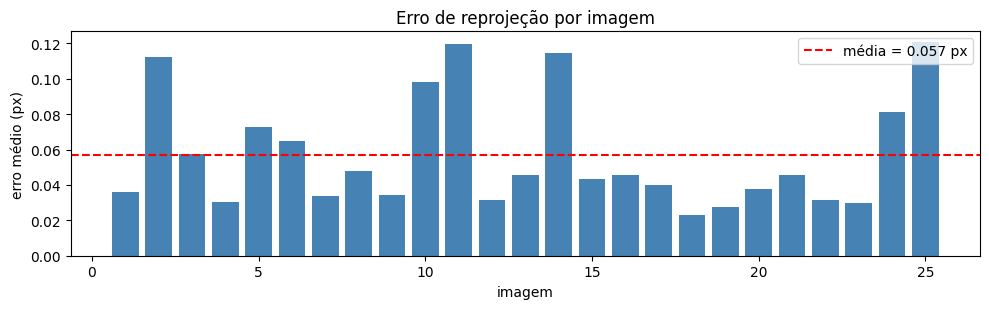

In [ ]:
# ===== CALIBRAÇÃO =====
rms, K, dist, rvecs, tvecs, std_int, std_ext, err_views = cv2.calibrateCameraExtended(
    obj_pts, img_pts, TAM, None, None, criteria=CRIT)
dist = dist.ravel()
std_int = std_int.ravel()

np.set_printoptions(suppress=True, precision=4)
print(f"erro RMS de reprojeção: {rms:.4f} px\n")
print("K =\n", K)
print("\ndistorção [k1 k2 p1 p2 k3] =", dist)
print(f"\nincerteza (1 desvio): fx ±{std_int[0]:.2f}  fy ±{std_int[1]:.2f}  "
      f"cx ±{std_int[2]:.2f}  cy ±{std_int[3]:.2f} px")

# campo de visão e erro médio por imagem
fov_x = 2 * np.degrees(np.arctan(TAM[0] / (2 * K[0, 0])))
fov_y = 2 * np.degrees(np.arctan(TAM[1] / (2 * K[1, 1])))
erros = []
for o, i, r, t in zip(obj_pts, img_pts, rvecs, tvecs):
    proj, _ = cv2.projectPoints(o, r, t, K, dist)
    erros.append(np.linalg.norm(proj.reshape(-1, 2) - i.reshape(-1, 2), axis=1).mean())
erros = np.array(erros)
print(f"campo de visão: {fov_x:.1f}° x {fov_y:.1f}°")
print(f"erro médio por imagem: {erros.mean():.4f} px (mín {erros.min():.4f}, máx {erros.max():.4f})")

RESULTADOS.update(rms=float(rms), K=K.tolist(), dist=dist.tolist(), std=std_int[:4].tolist(),
                  fov=[float(fov_x), float(fov_y)], erro_medio=float(erros.mean()),
                  erro_max=float(erros.max()), tam=list(TAM))

np.savez(os.path.join(PASTA_DADOS, "calibracao.npz"), K=K, dist=dist, tam=TAM, rms=rms)

plt.figure(figsize=(10, 3.2))
plt.bar(range(1, len(erros) + 1), erros, color="steelblue")
plt.axhline(erros.mean(), color="r", ls="--", label=f"média = {erros.mean():.3f} px")
plt.xlabel("imagem"); plt.ylabel("erro médio (px)"); plt.title("Erro de reprojeção por imagem")
plt.legend(); plt.tight_layout(); salvar_fig("erro_por_imagem.png"); plt.show()

In [ ]:
# ===== COMPARAÇÃO COM A VERDADE (só para as sintéticas) =====
if USAR_SINTETICAS:
    verd = np.load(os.path.join(ENTRADA, "verdade_sintetica.npz"), allow_pickle=True)
    nomes = ["fx", "fy", "cx", "cy", "k1", "k2", "p1", "p2", "k3"]
    real = [verd["K"][0,0], verd["K"][1,1], verd["K"][0,2], verd["K"][1,2], *verd["dist"]]
    est  = [K[0,0], K[1,1], K[0,2], K[1,2], *dist]
    print(f"{'':4}{'real':>11}{'estimado':>11}{'erro':>10}")
    tabela = []
    for n, r, e in zip(nomes, real, est):
        print(f"{n:4}{r:11.4f}{e:11.4f}{e - r:10.4f}")
        tabela.append([n, float(r), float(e)])
    RESULTADOS["verdade"] = tabela

           real   estimado      erro
fx    1400.0000  1399.9347   -0.0653
fy    1395.0000  1395.0089    0.0089
cx     810.0000   809.7056   -0.2944
cy     590.0000   590.0817    0.0817
k1      -0.2800    -0.2803   -0.0003
k2       0.1200     0.1205    0.0005
p1       0.0010     0.0010   -0.0000
p2      -0.0015    -0.0015    0.0000
k3      -0.0200    -0.0204   -0.0004


desvio das linhas do tabuleiro em relação a uma reta: 0.667 px -> 0.024 px


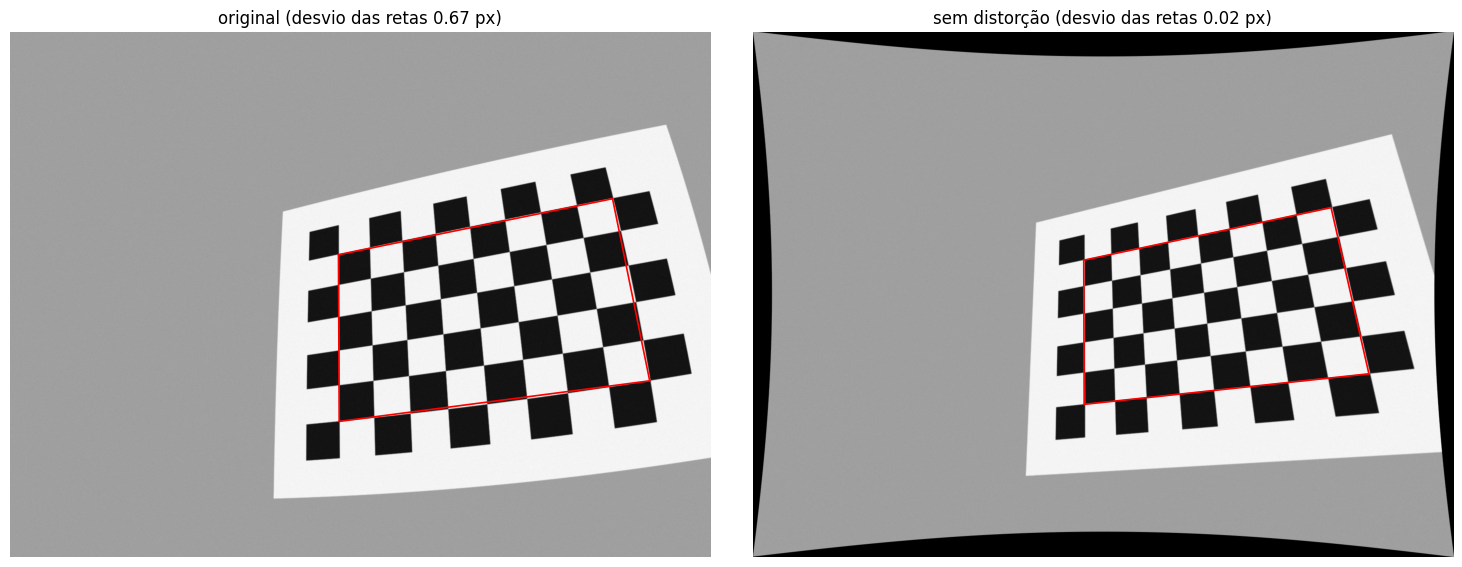

In [ ]:
# ===== REMOÇÃO DA DISTORÇÃO =====
ALPHA = 1   # 1 = mantém a imagem inteira (bordas pretas aparecem); 0 = recorta só a área válida
K_novo, roi = cv2.getOptimalNewCameraMatrix(K, dist, TAM, alpha=ALPHA, newImgSize=TAM)
mapx, mapy = cv2.initUndistortRectifyMap(K, dist, None, K_novo, TAM, cv2.CV_32FC1)

def corrigir(img):
    return cv2.remap(img, mapx, mapy, cv2.INTER_LINEAR)

def retidao(c):
    # desvio médio (px) dos cantos em relação à reta ajustada em cada linha do tabuleiro
    c = c.reshape(CANTOS[1], CANTOS[0], 2); d = []
    for linha in list(c) + list(c.transpose(1, 0, 2)):    # linhas e colunas
        vx, vy, x0, y0 = cv2.fitLine(linha.astype(np.float32), cv2.DIST_L2, 0, 0.01, 0.01).ravel()
        d.append(np.abs((linha[:,0]-x0)*vy - (linha[:,1]-y0)*vx).mean())
    return float(np.mean(d))

# maior tabuleiro na imagem = linhas longas, que atravessam regiões com distorção forte
area = [cv2.contourArea(cv2.convexHull(i.reshape(-1, 2))) for i in img_pts]
k = int(np.argmax(area))
orig = carregar(usadas[k]); corr = corrigir(orig)
c_orig = img_pts[k]
c_corr = cv2.undistortPoints(c_orig, K, dist, P=K_novo)
r0, r1 = retidao(c_orig), retidao(c_corr)
print(f"desvio das linhas do tabuleiro em relação a uma reta: {r0:.3f} px -> {r1:.3f} px")
RESULTADOS.update(retidao_antes=r0, retidao_depois=r1)

fig, ax = plt.subplots(1, 2, figsize=(15, 5.6))
for a, im, c, tit in [(ax[0], orig, c_orig, f"original (desvio das retas {r0:.2f} px)"),
                      (ax[1], corr, c_corr, f"sem distorção (desvio das retas {r1:.2f} px)")]:
    a.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
    c = c.reshape(CANTOS[1], CANTOS[0], 2)
    for linha in [c[0], c[-1], c[:, 0], c[:, -1]]:       # retas pelas extremidades
        a.plot([linha[0,0], linha[-1,0]], [linha[0,1], linha[-1,1]], "r-", lw=1.2)
    a.set_title(tit); a.axis("off")
plt.tight_layout(); salvar_fig("remocao_distorcao.png"); plt.show()

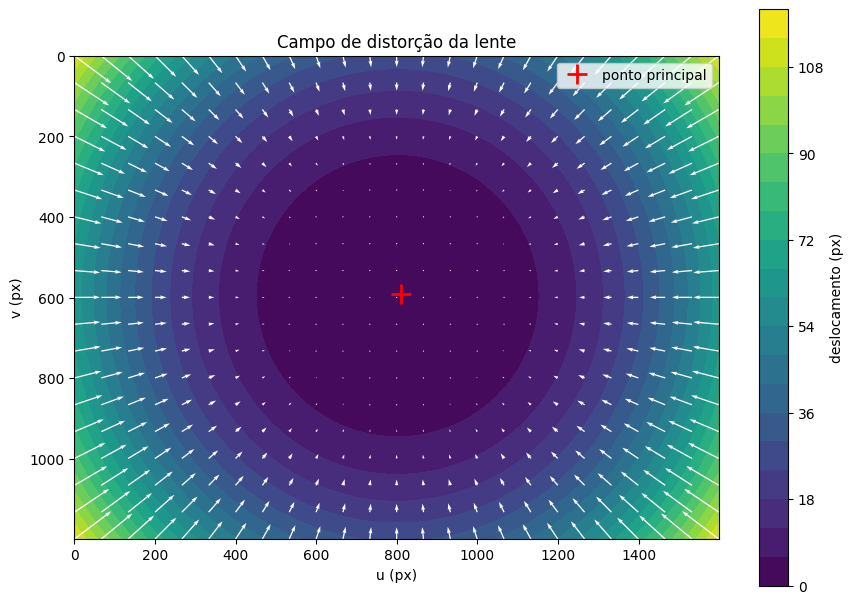

deslocamento máximo (canto da imagem): 114.8 px


In [ ]:
# ===== CAMPO DE DISTORÇÃO: quanto cada pixel se desloca =====
gx, gy = np.meshgrid(np.linspace(0, TAM[0]-1, 25), np.linspace(0, TAM[1]-1, 19))
ideal = np.stack([gx.ravel(), gy.ravel()], 1).astype(np.float32)
# pixel ideal (sem distorção) -> onde ele aparece na foto real
raio = cv2.undistortPoints(ideal.reshape(-1,1,2), K, np.zeros(5)).reshape(-1, 2)
raio3 = np.hstack([raio, np.ones((len(raio), 1))])
real_px = cv2.projectPoints(raio3, np.zeros(3), np.zeros(3), K, dist)[0].reshape(-1, 2)
desl = real_px - ideal

# mapa contínuo do deslocamento
fx_, fy_ = np.meshgrid(np.linspace(0, TAM[0]-1, 160), np.linspace(0, TAM[1]-1, 120))
id2 = np.stack([fx_.ravel(), fy_.ravel()], 1).astype(np.float32)
r2 = cv2.undistortPoints(id2.reshape(-1,1,2), K, np.zeros(5)).reshape(-1, 2)
rp2 = cv2.projectPoints(np.hstack([r2, np.ones((len(r2),1))]), np.zeros(3), np.zeros(3), K, dist)[0].reshape(-1,2)
mapa = np.linalg.norm(rp2 - id2, axis=1).reshape(fx_.shape)

plt.figure(figsize=(9, 6.2))
cf = plt.contourf(fx_, fy_, mapa, levels=20, cmap="viridis")
plt.colorbar(cf, label="deslocamento (px)")
plt.quiver(ideal[:,0], ideal[:,1], desl[:,0], desl[:,1], color="w", angles="xy",
           scale_units="xy", scale=1, width=0.002)
plt.plot(K[0,2], K[1,2], "r+", ms=14, mew=2, label="ponto principal")
plt.gca().invert_yaxis(); plt.gca().set_aspect("equal"); plt.legend(loc="upper right")
plt.title("Campo de distorção da lente"); plt.xlabel("u (px)"); plt.ylabel("v (px)")
plt.tight_layout(); salvar_fig("campo_distorcao.png"); plt.show()

print(f"deslocamento máximo (canto da imagem): {mapa.max():.1f} px")
RESULTADOS["desl_max"] = float(mapa.max())

sint_teste_00.png: distância 733 mm | erro com distorção 0.049 px (máx 0.134) | ignorando distorção 7.86 px
   ponto 3D [ 0. 75.  0.] mm -> câmera [ 61.7  94.2 719.4] mm -> pixel previsto [928.95 771.54] | detectado [928.96 771.58]
sint_teste_01.png: distância 573 mm | erro com distorção 0.140 px (máx 0.283) | ignorando distorção 9.33 px
   ponto 3D [ 0. 75.  0.] mm -> câmera [  8.  114.6 549.5] mm -> pixel previsto [829.68 877.73] | detectado [829.66 877.69]
sint_teste_02.png: distância 575 mm | erro com distorção 0.132 px (máx 0.293) | ignorando distorção 10.52 px
   ponto 3D [ 0. 75.  0.] mm -> câmera [ 72.8  40.2 564.4] mm -> pixel previsto [989.   688.78] | detectado [988.98 688.75]


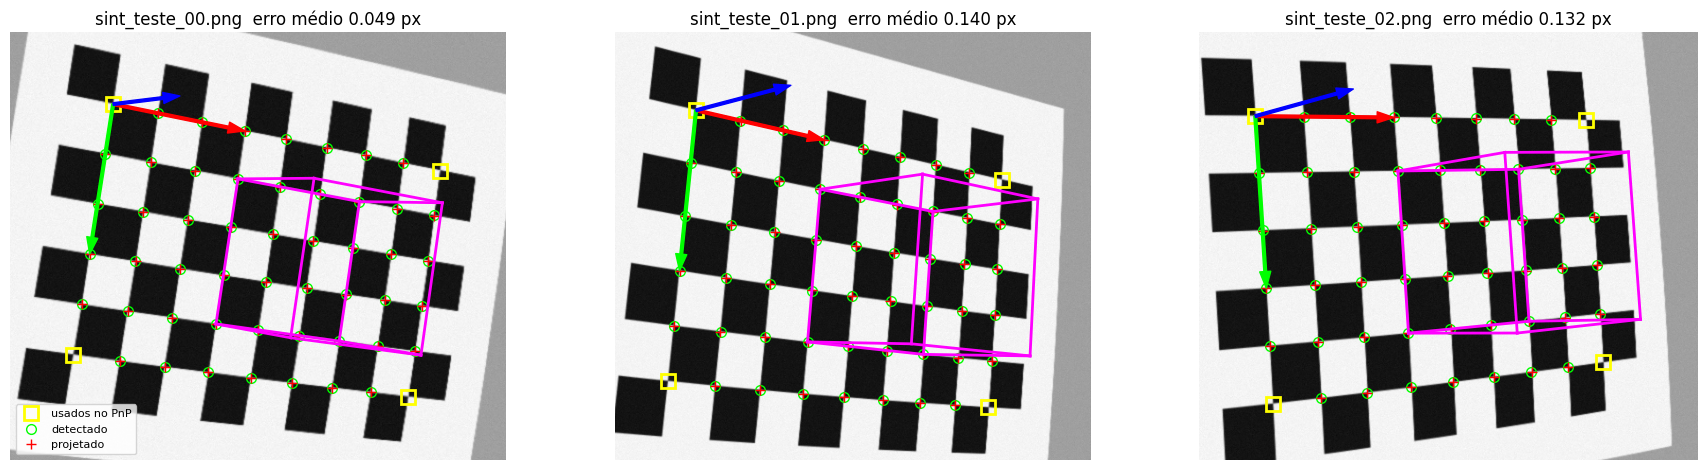

In [ ]:
# ===== EXPERIMENTO 3D -> 2D =====
ids_ext = [0, CANTOS[0]-1, CANTOS[0]*(CANTOS[1]-1), CANTOS[0]*CANTOS[1]-1]   # 4 cantos externos
ids_int = [i for i in range(len(OBJP)) if i not in ids_ext]

def cubo(x0, y0, lado):
    base = np.array([[x0, y0, 0], [x0+lado, y0, 0], [x0+lado, y0+lado, 0], [x0, y0+lado, 0]], np.float32)
    topo = base.copy(); topo[:, 2] = -lado          # Z negativo = "para fora" do tabuleiro
    return np.vstack([base, topo])

CUBO = cubo(3*QUAD_MM, 1*QUAD_MM, 3*QUAD_MM)
EIXOS = np.float32([[0,0,0], [3*QUAD_MM,0,0], [0,3*QUAD_MM,0], [0,0,-3*QUAD_MM]])
ARESTAS = [(0,1),(1,2),(2,3),(3,0),(4,5),(5,6),(6,7),(7,4),(0,4),(1,5),(2,6),(3,7)]

fotos_exp = testes if testes else usadas[-3:]
tab_exp = []
fig, ax = plt.subplots(1, len(fotos_exp), figsize=(6*len(fotos_exp), 4.8))
ax = np.atleast_1d(ax)
for a, p in zip(ax, fotos_exp):
    img = carregar(p); c = detectar(img)
    if c is None:
        print("não detectado:", p); continue
    c = c.reshape(-1, 2)
    ok, r, t = cv2.solvePnP(OBJP[ids_ext], c[ids_ext], K, dist, flags=cv2.SOLVEPNP_IPPE)
    proj  = cv2.projectPoints(OBJP[ids_int], r, t, K, dist)[0].reshape(-1, 2)
    proj0 = cv2.projectPoints(OBJP[ids_int], r, t, K, np.zeros(5))[0].reshape(-1, 2)
    e  = np.linalg.norm(proj  - c[ids_int], axis=1)
    e0 = np.linalg.norm(proj0 - c[ids_int], axis=1)
    dist_cam = float(np.linalg.norm(t))
    tab_exp.append([os.path.basename(p), dist_cam, float(e.mean()), float(e.max()), float(e0.mean())])
    print(f"{os.path.basename(p)}: distância {dist_cam:.0f} mm | erro com distorção "
          f"{e.mean():.3f} px (máx {e.max():.3f}) | ignorando distorção {e0.mean():.2f} px")

    # exemplo de um ponto: coordenada 3D -> pixel
    j = ids_int[len(ids_int)//2]
    Xc = cv2.Rodrigues(r)[0] @ OBJP[j] + t.ravel()
    print(f"   ponto 3D {OBJP[j]} mm -> câmera {np.round(Xc,1)} mm -> pixel previsto "
          f"{np.round(proj[ids_int.index(j)],2)} | detectado {np.round(c[j],2)}")

    a.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    a.plot(c[ids_ext,0], c[ids_ext,1], "s", mfc="none", mec="yellow", ms=10, mew=2, label="usados no PnP")
    a.plot(c[ids_int,0], c[ids_int,1], "o", mfc="none", mec="lime", ms=7, label="detectado")
    a.plot(proj[:,0], proj[:,1], "r+", ms=7, label="projetado")
    pc = cv2.projectPoints(CUBO, r, t, K, dist)[0].reshape(-1, 2)
    for i, j2 in ARESTAS:
        a.plot(pc[[i,j2],0], pc[[i,j2],1], "-", color="magenta", lw=2)
    pe = cv2.projectPoints(EIXOS, r, t, K, dist)[0].reshape(-1, 2)
    for k2, cor in zip([1,2,3], ["red", "lime", "blue"]):
        a.annotate("", pe[k2], pe[0], arrowprops=dict(color=cor, width=2, headwidth=8))
    todos = np.vstack([c, pc, pe]); m = 60                # enquadra o tabuleiro
    a.set_xlim(max(0, todos[:,0].min()-m), min(img.shape[1], todos[:,0].max()+m))
    a.set_ylim(min(img.shape[0], todos[:,1].max()+m), max(0, todos[:,1].min()-m))
    a.set_title(f"{os.path.basename(p)}  erro médio {e.mean():.3f} px"); a.axis("off")
ax[0].legend(loc="lower left", fontsize=8)
plt.tight_layout(); salvar_fig("projecao_3d.png"); plt.show()
RESULTADOS["experimento"] = tab_exp

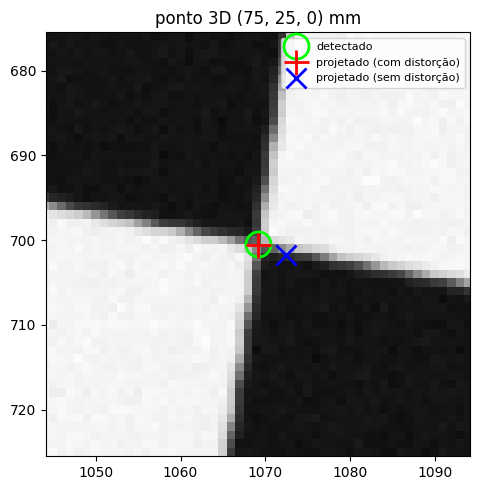

In [ ]:
# ===== AMPLIAÇÃO: detectado x projetado (mostra o erro subpixel) =====
p = fotos_exp[0]; img = carregar(p); c = detectar(img).reshape(-1, 2)
ok, r, t = cv2.solvePnP(OBJP[ids_ext], c[ids_ext], K, dist, flags=cv2.SOLVEPNP_IPPE)
proj  = cv2.projectPoints(OBJP, r, t, K, dist)[0].reshape(-1, 2)
proj0 = cv2.projectPoints(OBJP, r, t, K, np.zeros(5))[0].reshape(-1, 2)
j = ids_int[CANTOS[0] + 1]                         # um canto perto da borda do tabuleiro
x0, y0 = c[j]; R_ = 25
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB), interpolation="nearest")
ax.plot(*c[j], "o", mfc="none", mec="lime", ms=18, mew=2, label="detectado")
ax.plot(*proj[j], "r+", ms=18, mew=2, label="projetado (com distorção)")
ax.plot(*proj0[j], "bx", ms=14, mew=2, label="projetado (sem distorção)")
ax.set_xlim(x0-R_, x0+R_); ax.set_ylim(y0+R_, y0-R_); ax.legend(fontsize=8)
ax.set_title(f"ponto 3D ({OBJP[j,0]:.0f}, {OBJP[j,1]:.0f}, 0) mm")
plt.tight_layout(); salvar_fig("projecao_zoom.png"); plt.show()

In [ ]:
# ===== CALIBRAÇÃO ESTÉREO =====
pares_e, pares_d = listar(PASTA_ESQ), listar(PASTA_DIR)
FAZER_ESTEREO = len(pares_e) > 0 and len(pares_e) == len(pares_d)
print("pares estéreo:", len(pares_e), "| executar:", FAZER_ESTEREO)

if FAZER_ESTEREO:
    K1, d1 = K, dist                  # mesma câmera/modelo nas duas posições
    K2, d2 = K, dist
    o_s, e_s, d_s = [], [], []
    for pe, pd in zip(pares_e, pares_d):
        ce, cd = detectar(carregar(pe)), detectar(carregar(pd))
        if ce is not None and cd is not None:
            o_s.append(OBJP); e_s.append(ce); d_s.append(cd)
    rms_s, _, _, _, _, R_s, T_s, E_s, F_s = cv2.stereoCalibrate(
        o_s[:-1], e_s[:-1], d_s[:-1], K1, d1, K2, d2, TAM,
        flags=cv2.CALIB_FIX_INTRINSIC, criteria=CRIT)          # último par fica para teste
    base_est = float(np.linalg.norm(T_s))
    ang = float(np.degrees(np.linalg.norm(cv2.Rodrigues(R_s)[0])))
    print(f"RMS estéreo: {rms_s:.4f} px | pares usados: {len(o_s)-1}")
    print("R =\n", R_s, f"\n(rotação entre câmeras: {ang:.3f}°)")
    print("T =", T_s.ravel(), "mm")
    print(f"base (distância entre câmeras): {base_est:.2f} mm")
    RESULTADOS.update(estereo_rms=float(rms_s), estereo_T=T_s.ravel().tolist(),
                      estereo_base=base_est, estereo_ang=ang, estereo_pares=len(o_s)-1)

pares estéreo: 12 | executar: True
RMS estéreo: 0.0468 px | pares usados: 11
R =
 [[ 1.  0. -0.]
 [-0.  1. -0.]
 [ 0.  0.  1.]] 
(rotação entre câmeras: 0.000°)
T = [-120.0016    0.0061    0.0165] mm
base (distância entre câmeras): 120.00 mm


lado do quadrado triangulado: 25.000 ± 0.035 mm (real 25.0 mm)
diferença triangulação x PnP: média 0.065 mm, máx 0.238 mm

ponto escolhido: pixel esq [950.5 645.3], pixel dir [580.4 645.1]
  posição triangulada: [ 45.56  17.9  451.2 ] mm  | profundidade Z = 451.2 mm
  posição de referência: [ 45.55  17.9  451.15] mm


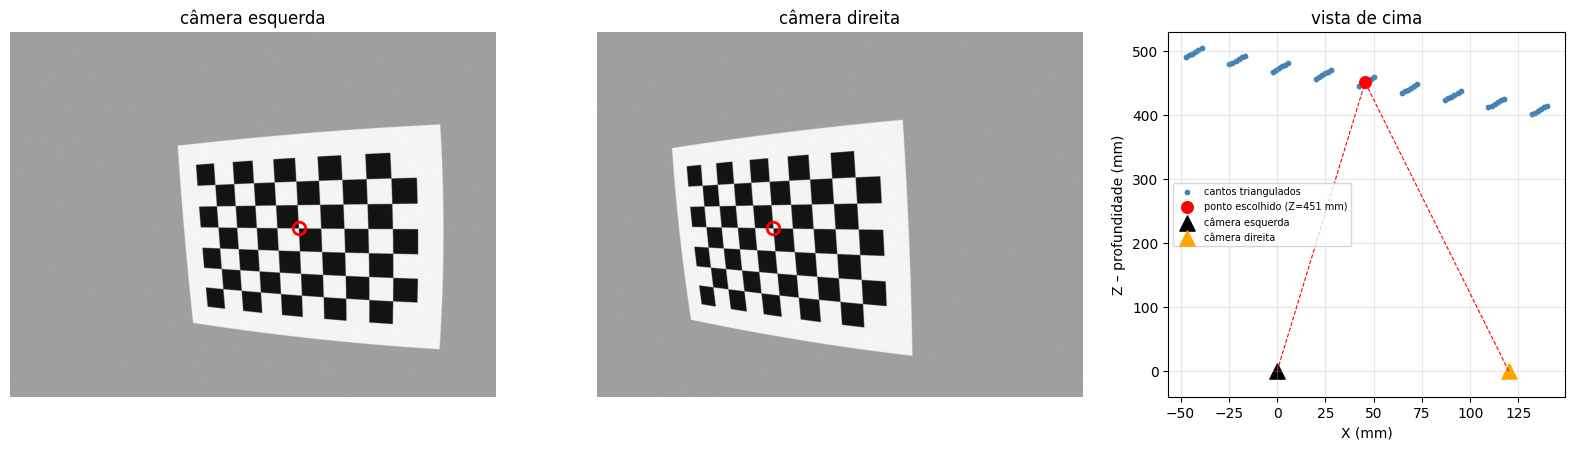

In [ ]:
# ===== TRIANGULAÇÃO de pontos presentes nas duas imagens =====
if FAZER_ESTEREO:
    ce, cd = e_s[-1], d_s[-1]                            # par de teste
    # 1) remove a distorção e passa para coordenadas normalizadas
    ne = cv2.undistortPoints(ce, K1, d1).reshape(-1, 2).T
    nd = cv2.undistortPoints(cd, K2, d2).reshape(-1, 2).T
    P1 = np.hstack([np.eye(3), np.zeros((3, 1))])
    P2 = np.hstack([R_s, T_s.reshape(3, 1)])
    Xh = cv2.triangulatePoints(P1, P2, ne, nd)
    X = (Xh[:3] / Xh[3]).T                              # pontos 3D no sistema da câmera esquerda (mm)

    # 2) conferência 1: tamanho dos quadrados reconstruídos
    G = X.reshape(CANTOS[1], CANTOS[0], 3)
    lados = np.concatenate([np.linalg.norm(np.diff(G, axis=1), axis=2).ravel(),
                            np.linalg.norm(np.diff(G, axis=0), axis=2).ravel()])
    print(f"lado do quadrado triangulado: {lados.mean():.3f} ± {lados.std():.3f} mm (real {QUAD_MM} mm)")

    # 3) conferência 2: comparação com a posição dada pela pose (solvePnP) na câmera esquerda
    ok, r, t = cv2.solvePnP(OBJP, ce, K1, d1)
    X_ref = (cv2.Rodrigues(r)[0] @ OBJP.T + t).T
    dif = np.linalg.norm(X - X_ref, axis=1)
    print(f"diferença triangulação x PnP: média {dif.mean():.3f} mm, máx {dif.max():.3f} mm")

    # 4) um ponto específico, como pede o enunciado
    j = CANTOS[0] * 2 + 4
    print(f"\nponto escolhido: pixel esq {np.round(ce[j].ravel(),1)}, pixel dir {np.round(cd[j].ravel(),1)}")
    print(f"  posição triangulada: {np.round(X[j], 2)} mm  | profundidade Z = {X[j,2]:.1f} mm")
    print(f"  posição de referência: {np.round(X_ref[j], 2)} mm")
    RESULTADOS.update(tri_lado=[float(lados.mean()), float(lados.std())],
                      tri_dif=[float(dif.mean()), float(dif.max())],
                      tri_ponto=X[j].tolist(), tri_ref=X_ref[j].tolist(),
                      tri_px=[ce[j].ravel().tolist(), cd[j].ravel().tolist()])

    fig = plt.figure(figsize=(16, 4.6))
    gs = fig.add_gridspec(1, 3, width_ratios=[1.3, 1.3, 1])
    for k, (pp, cc, tit) in enumerate([(pares_e[-1], ce, "câmera esquerda"),
                                       (pares_d[-1], cd, "câmera direita")]):
        a = fig.add_subplot(gs[0, k])
        a.imshow(cv2.cvtColor(carregar(pp), cv2.COLOR_BGR2RGB))
        a.plot(*cc[j].ravel(), "ro", ms=9, mfc="none", mew=2)
        a.set_title(tit); a.axis("off")
    a = fig.add_subplot(gs[0, 2])                      # vista de cima (plano X-Z)
    a.scatter(X[:,0], X[:,2], s=10, c="steelblue", label="cantos triangulados")
    a.scatter(X[j,0], X[j,2], s=70, c="r", label=f"ponto escolhido (Z={X[j,2]:.0f} mm)")
    cam_d = -R_s.T @ T_s.ravel()
    a.scatter([0], [0], marker="^", s=120, c="k", label="câmera esquerda")
    a.scatter([cam_d[0]], [cam_d[2]], marker="^", s=120, c="orange", label="câmera direita")
    for cam in [np.zeros(3), cam_d]:
        a.plot([cam[0], X[j,0]], [cam[2], X[j,2]], "r--", lw=0.8)   # raios que se cruzam
    a.set_xlabel("X (mm)"); a.set_ylabel("Z – profundidade (mm)"); a.set_ylim(-40, None)
    a.legend(fontsize=7, loc="center left"); a.set_title("vista de cima"); a.grid(alpha=.3)
    plt.tight_layout(); salvar_fig("estereo_triangulacao.png"); plt.show()

In [ ]:
# ===== SALVA TODAS AS FOTOS SEM DISTORÇÃO =====
for p in usadas + testes:
    nome = os.path.splitext(os.path.basename(p))[0] + "_corrigida.png"
    cv2.imwrite(os.path.join(PASTA_CORRIG, nome), corrigir(carregar(p)))
print(len(os.listdir(PASTA_CORRIG)), "imagens corrigidas em", PASTA_CORRIG)

28 imagens corrigidas em /content/drive/MyDrive/visao_computacional/calibracao/sintetico/saida/imagens_sem_distorcao


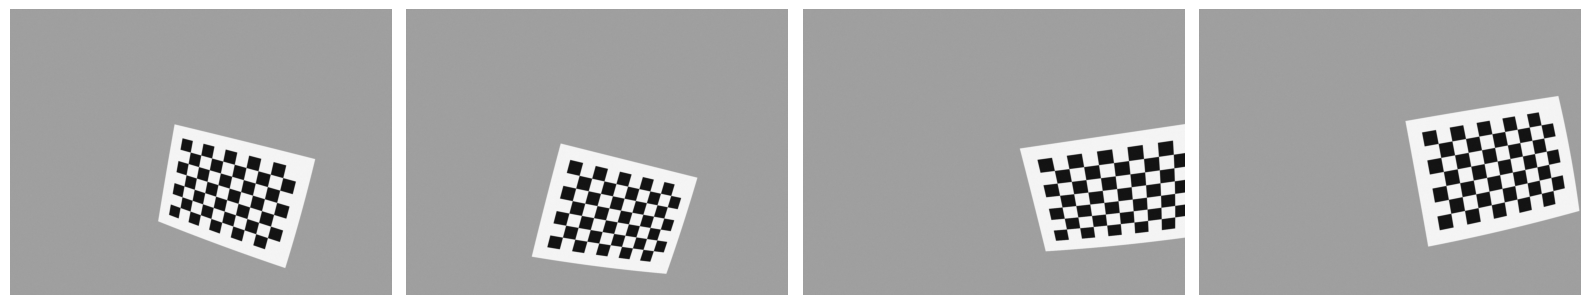

===== RESUMO =====
fotos: 25/25 | resolução 1600x1200
fx=1399.93 fy=1395.01 cx=809.71 cy=590.08
dist = [-0.2803  0.1205  0.001  -0.0015 -0.0204]
RMS = 0.0725 px | FOV 59.5° x 46.5°

--- tabelas LaTeX (também em dados/tabelas_latex.txt) ---
$f_x$ (px) & 1399{,}93 & 0{,}36 \\
$f_y$ (px) & 1395{,}01 & 0{,}35 \\
$c_x$ (px) & 809{,}71 & 0{,}42 \\
$c_y$ (px) & 590{,}08 & 0{,}33 \\
$k_1$ & -0{,}2803 & 0{,}0007 \\
$k_2$ & 0{,}1205 & 0{,}0024 \\
$p_1$ & 0{,}0010 & 0{,}0000 \\
$p_2$ & -0{,}0015 & 0{,}0001 \\
$k_3$ & -0{,}0204 & 0{,}0031 \\
RMS (px) & \multicolumn{2}{c}{0{,}073} \\

% experimento 3D -> 2D
Teste 1 & 733 & 0{,}049 & 0{,}134 & 7{,}86 \\
Teste 2 & 573 & 0{,}140 & 0{,}283 & 9{,}33 \\
Teste 3 & 575 & 0{,}132 & 0{,}293 & 10{,}52 \\

===== CONTEÚDO DA PASTA DE SAÍDA =====
saida/ (0 arquivos)
   dados/ (5 arquivos)
   figuras/ (8 arquivos)
   imagens_sem_distorcao/ (28 arquivos)


In [ ]:
# ===== FIGURA DE EXEMPLOS =====
fig, ax = plt.subplots(1, 4, figsize=(16, 3.2))
for a, p in zip(ax, usadas[::max(1, len(usadas)//4)][:4]):
    a.imshow(cv2.cvtColor(carregar(p), cv2.COLOR_BGR2RGB)); a.axis("off")
plt.tight_layout(); salvar_fig("exemplos_calibracao.png"); plt.show()

# ===== DADOS =====
with open(os.path.join(PASTA_DADOS, "resultados.json"), "w") as f:
    json.dump(RESULTADOS, f, indent=2, ensure_ascii=False)

np.savetxt(os.path.join(PASTA_DADOS, "matriz_K.txt"), K, fmt="%.6f")
np.savetxt(os.path.join(PASTA_DADOS, "distorcao.txt"), dist.reshape(1, -1), fmt="%.8f",
           header="k1 k2 p1 p2 k3")

# linhas prontas para colar na tabela do artigo (LaTeX, vírgula decimal)
br = lambda x, n=2: f"{x:.{n}f}".replace(".", "{,}")
linhas = []
for nome, val, sd in [("f_x", K[0,0], std_int[0]), ("f_y", K[1,1], std_int[1]),
                      ("c_x", K[0,2], std_int[2]), ("c_y", K[1,2], std_int[3])]:
    linhas.append(f"${nome}$ (px) & {br(val)} & {br(sd)} \\\\")
for nome, val, sd in zip(["k_1","k_2","p_1","p_2","k_3"], dist, std_int[4:9]):
    linhas.append(f"${nome}$ & {br(val,4)} & {br(sd,4)} \\\\")
linhas.append(f"RMS (px) & \\multicolumn{{2}}{{c}}{{{br(rms,3)}}} \\\\")
linhas.append("")
linhas.append("% experimento 3D -> 2D")
for n, (nome, dcam, em, emax, e0) in enumerate(RESULTADOS.get("experimento", []), 1):
    linhas.append(f"Teste {n} & {dcam:.0f} & {br(em,3)} & {br(emax,3)} & {br(e0)} \\\\")
with open(os.path.join(PASTA_DADOS, "tabelas_latex.txt"), "w") as f:
    f.write("\n".join(linhas))

# ===== RESUMO =====
print("===== RESUMO =====")
print(f"fotos: {RESULTADOS['n_usadas']}/{RESULTADOS['n_fotos']} | resolução {TAM[0]}x{TAM[1]}")
print(f"fx={K[0,0]:.2f} fy={K[1,1]:.2f} cx={K[0,2]:.2f} cy={K[1,2]:.2f}")
print("dist =", np.round(dist, 5))
print(f"RMS = {rms:.4f} px | FOV {fov_x:.1f}° x {fov_y:.1f}°")
print("\n--- tabelas LaTeX (também em dados/tabelas_latex.txt) ---")
print("\n".join(linhas))

print("\n===== CONTEÚDO DA PASTA DE SAÍDA =====")
for raiz, _, arqs in sorted(os.walk(SAIDA)):
    nivel = raiz.replace(SAIDA, "").count(os.sep)
    print("   " * nivel + os.path.basename(raiz) + "/", f"({len(arqs)} arquivos)")

In [ ]:
# ===== (opcional) BAIXA A SAÍDA INTEIRA EM .ZIP =====
import shutil
zip_saida = shutil.make_archive(os.path.join(BASE, "saida_calibracao"), "zip", SAIDA)
print("zip criado:", zip_saida)
if NO_COLAB:
    from google.colab import files
    files.download(zip_saida)

zip criado: /content/drive/MyDrive/visao_computacional/calibracao/sintetico/saida_calibracao.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>